In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import random

In [ ]:
!unzip /content/chest_xray.zip

Archive:  /content/chest_xray.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/chest_xray.zip or
        /content/chest_xray.zip.zip, and cannot find /content/chest_xray.zip.ZIP, period.


In [ ]:
!unzip ResNetchest_xray.zip

Archive:  ResNetchest_xray.zip
   creating: chest_xray/
   creating: chest_xray/test/
   creating: chest_xray/test/NORMAL/
  inflating: chest_xray/test/NORMAL/IM-0001-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0003-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0005-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0006-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0007-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0009-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0010-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0011-0001-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0011-0001-0002.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0011-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0013-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0015-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0016-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0017-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0019-0001.jpeg  
  inflating: chest_xray/tes

In [ ]:
ls

test/  train/


In [ ]:
cd train

/content/chest_xray/train


In [ ]:
ls

NORMAL/  PNEUMONIA/


In [ ]:
!ls NORMAL | wc -l
!ls PNEUMONIA | wc -l

350
350


In [ ]:
img_size = 224
batch_size = 32
epochs = 15

In [ ]:
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    '/content/chest_xray/train',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    '/content/chest_xray/test',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 700 images belonging to 2 classes.
Found 300 images belonging to 2 classes.


In [ ]:
print(train_generator.samples)
print(test_generator.samples)
print(train_generator.class_indices)

700
300
{'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

NameError: name 'Model' is not defined

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 228s 10s/step - accuracy: 0.5753 - loss: 0.8221 - val_accuracy: 0.7900 - val_loss: 0.4341
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 193s 9s/step - accuracy: 0.8666 - loss: 0.3212 - val_accuracy: 0.7567 - val_loss: 0.4494
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 194s 9s/step - accuracy: 0.9075 - loss: 0.2231 - val_accuracy: 0.7400 - val_loss: 0.4838
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 220s 10s/step - accuracy: 0.8692 - loss: 0.2700 - val_accuracy: 0.7333 - val_loss: 0.5123
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 227s 10s/step - accuracy: 0.9382 - loss: 0.1787 - val_accuracy: 0.7133 - val_loss: 0.5568
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 230s 9s/step - accuracy: 0.8894 - loss: 0.2301 - val_accuracy: 0.7533 - val_loss: 0.4751
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 195s 9s/step - accuracy: 0.9368 - loss: 0.1727 - val_accuracy: 0.7133 - val_loss: 0.5754
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 202s 9s/step - accuracy: 0.9117 - loss: 0.1975 - val_accuracy: 0.7333 

In [ ]:
model.save('/content/drive/MyDrive/models/resnet_small_70_30_bs32_15ep.h5')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns

In [ ]:
results_path = "/content/drive/MyDrive/experiment_results/resnet_small_70_30"
os.makedirs(results_path, exist_ok=True)

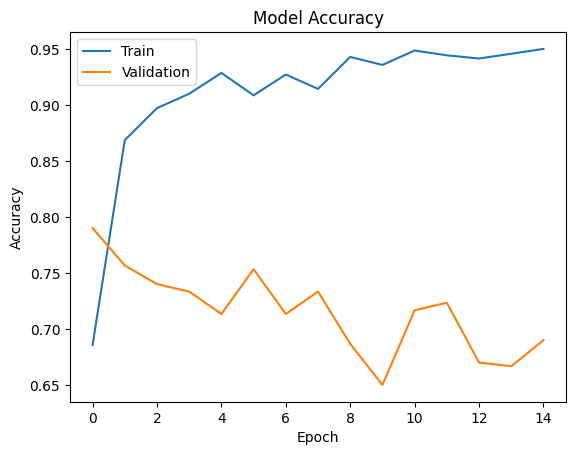

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.savefig(results_path + "/accuracy_plot.png")
plt.show()

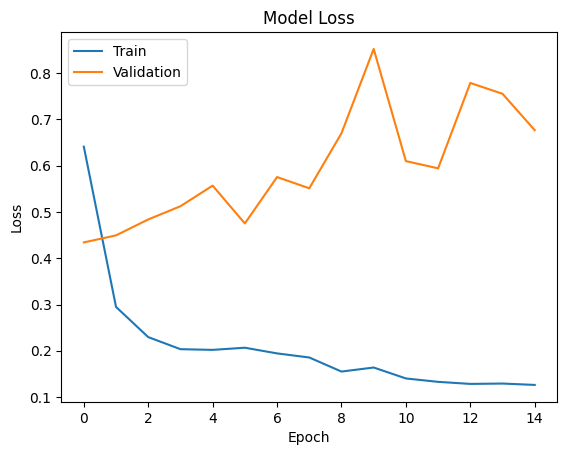

In [ ]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.savefig(results_path + "/loss_plot.png")
plt.show()

In [ ]:
test_generator.reset()
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).ravel()
y_true = test_generator.classes

10/10 ━━━━━━━━━━━━━━━━━━━━ 63s 6s/step


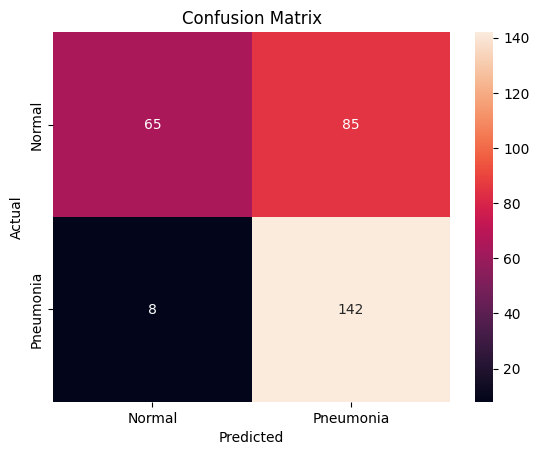

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.savefig(results_path + "/confusion_matrix.png")
plt.show()

In [ ]:
report = classification_report(y_true, y_pred, target_names=['Normal','Pneumonia'])
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

print(report)
print("Weighted F1 Score:", weighted_f1)

              precision    recall  f1-score   support

      Normal       0.89      0.43      0.58       150
   Pneumonia       0.63      0.95      0.75       150

    accuracy                           0.69       300
   macro avg       0.76      0.69      0.67       300
weighted avg       0.76      0.69      0.67       300

Weighted F1 Score: 0.6681376455614897


In [ ]:
with open(results_path + "/classification_report.txt", "w") as f:
    f.write(report)
    f.write("\nWeighted F1 Score: " + str(weighted_f1))

In [ ]:
final_val_acc = history.history['val_accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]

with open(results_path + "/final_metrics.txt", "w") as f:
    f.write("Final Validation Accuracy: " + str(final_val_acc) + "\n")
    f.write("Final Validation Loss: " + str(final_val_loss) + "\n")
    f.write("Weighted F1 Score: " + str(weighted_f1))